In [ ]:

# DROPLET MICROFLUIDICS PHYSICS CALCULATIONS
# FLOW RATES, DIMENSIONLESS NUMBERS & DROPLETS PLOTS

# Purpose:
#   This script takes your experimental inputs (gas + liquid flow rates,
#   droplet counts, geometry, and fluid properties), converts units into
#   SI, computes velocities, then calculates dimensionless numbers:
#       - Capillary number (Ca): viscous vs surface tension forces
#       - Weber number (We): inertial vs surface tension forces
#       - Reynolds number (Re): inertial vs viscous forces
#   for continuous phases, and finally plots them.
#


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings

In [ ]:
# USER INPUTS
# This block collects experimental parameters from the user.
# IMPORTANT: These inputs must be in the units asked for, because we later
# convert them into SI (m^3/s, Pa*s, N/m, m, kg/m^3).
print("\n=== ENTER CONSTANT INPUT VALUES ===")

# Note: Gas flow rates (Qg), Liquid flow rates (Ql), and Droplet counts
# are now imported directly from the Excel file to prevent manual entry errors.

# Geometric diameters:
# d_i = liquid phase inner needle diameter (m) = 0.0003048
# d_o = outer diameter of the needle (for gas flow displacement)(m)= 0.0006096
# D_i = outlet tubing inner diameter (m)= 0.0024
d_i = float(input("Enter liquid phase inner needle diameter d in meters (m): "))
d_o = float(input("Enter liquid needle outer diameter d_o (m): "))
D_i = float(input("Enter outlet tubing inner diameter D in meters (m): "))

# Fluid properties: at 21 Degrees Celcius
#Gas (Continous phase) - Nitrogen
# rho_g = gas density (kg/m^3) = 1.155
# mu_g  = gas dynamic viscosity (Pa·s) = 17.63e-6
# sigma = Interfacial surface tension (N/m) = 0.0728 (air)
rho_g = float(input("Enter gas density (kg/m³): "))
mu_g = float(input("Enter gas viscosity (Pa·s): "))
sigma = float(input("Enter surface tension (N/m): "))




=== ENTER CONSTANT INPUT VALUES ===
Enter liquid phase inner needle diameter d in meters (m): 0.0003048
Enter liquid needle outer diameter d_o (m): 0.0006096
Enter outlet tubing inner diameter D in meters (m): 0.0024
Enter gas density (kg/m³): 1.155
Enter gas viscosity (Pa·s): 17.63e-6
Enter surface tension (N/m): 0.0728


In [ ]:
# 1. Silencing background chatter
warnings.filterwarnings('ignore', category=FutureWarning)

# 2. Reducing Significant Figures
def fmt_sf(x, n):
    if pd.isna(x) or x == "" or (isinstance(x, str) and x.strip() == ""):
        return ""
    try:
        val = float(x)
        if val == 0: return "0"
        return '{:g}'.format(float('{:.{p}g}'.format(val, p=n)))
    except:
        return x

# 3. Upload Excel file
uploader = widgets.FileUpload(accept='.xlsx, .xls', multiple=False)
button = widgets.Button(description="Generate Table", button_style='success')
output = widgets.Output(layout=widgets.Layout(max_height='600px', overflow_y='auto'))

display(uploader, button, output)

# 4. Excel Data Processing
def on_button_clicked(b):
    global final_df
    global raw_df

    with output:
        clear_output()
        if not uploader.value:
            return

        try:
            # Load Raw Content
            try:
                uploaded_file = uploader.value[0]
                content = uploaded_file.content
            except KeyError:
                file_name = list(uploader.value.keys())[0]
                content = uploader.value[file_name]['content']

            # Data Cleaning
            raw_df = pd.read_excel(io.BytesIO(content), header=None, skiprows=2)
            raw_df.columns = ['Qg', 'Ql', 'T1', 'T2', 'T3']
            raw_df['Qg'] = raw_df['Qg'].ffill()
            raw_df = raw_df.dropna(subset=['Ql', 'T1'])
            for col in raw_df.columns:
                raw_df[col] = pd.to_numeric(raw_df[col], errors='coerce')
            raw_df = raw_df.dropna(subset=['Ql', 'T1'])

            # Calculation (Averages, Droplet count, Volume)
            raw_df['Avg_C'] = raw_df[['T1', 'T2', 'T3']].mean(axis=1)
            raw_df['Std_C'] = raw_df[['T1', 'T2', 'T3']].std(axis=1, ddof=1)
            raw_df['V1'] = raw_df['Ql'] / raw_df['T1']
            raw_df['V2'] = raw_df['Ql'] / raw_df['T2']
            raw_df['V3'] = raw_df['Ql'] / raw_df['T3']
            raw_df['Avg_V'] = raw_df[['V1', 'V2', 'V3']].mean(axis=1)
            raw_df['Std_V'] = raw_df[['V1', 'V2', 'V3']].std(axis=1, ddof=1)

            # --- DIAMETER CALCULATIONS (mm) ---
            # Formula: d = [(6 * V * 1000) / pi]^(1/3)
            raw_df['D1'] = ((6 * raw_df['V1'] * 1000) / np.pi)**(1/3)
            raw_df['D2'] = ((6 * raw_df['V2'] * 1000) / np.pi)**(1/3)
            raw_df['D3'] = ((6 * raw_df['V3'] * 1000) / np.pi)**(1/3)
            raw_df['Avg_D'] = raw_df[['D1', 'D2', 'D3']].mean(axis=1)
            raw_df['Std_D'] = raw_df[['D1', 'D2', 'D3']].std(axis=1, ddof=1)

            # Dataframe Format
            formatted_rows = []
            unique_gases = raw_df['Qg'].unique()
            for i, qg in enumerate(unique_gases):
                gas_block = raw_df[raw_df['Qg'] == qg]
                for _, row in gas_block.iterrows():
                    formatted_rows.append({
                        ('Gas Flow', '(L/min)'): row['Qg'],
                        ('Liq Flow', '(mL/min)'): row['Ql'],
                        ('Count/min', 'T1'): row['T1'],
                        ('Count/min', 'T2'): row['T2'],
                        ('Count/min', 'T3'): row['T3'],
                        ('Avg Count', ''): row['Avg_C'],
                        ('Volume (mL)', 'T1'): row['V1'],
                        ('Volume (mL)', 'T2'): row['V2'],
                        ('Volume (mL)', 'T3'): row['V3'],
                        ('Avg Vol', '(mL)'): row['Avg_V'],
                        ('Diameter (mm)', 'T1'): row['D1'],
                        ('Diameter (mm)', 'T2'): row['D2'],
                        ('Diameter (mm)', 'T3'): row['D3'],
                        ('Avg Dia', '(mm)'): row['Avg_D'],
                        ('Dia std', ''): row['Std_D']
                    })
                if i < len(unique_gases) - 1:
                    formatted_rows.append({col: np.nan for col in formatted_rows[0].keys()})

            display_df = pd.DataFrame(formatted_rows)
            display_df.columns = pd.MultiIndex.from_tuples(display_df.columns)

            # Table Style Engine
            styled_df = display_df.style.format({
                ('Gas Flow', '(L/min)'): lambda x: fmt_sf(x, 2),
                ('Liq Flow', '(mL/min)'): lambda x: fmt_sf(x, 2),
                ('Count/min', 'T1'): lambda x: fmt_sf(x, 4),
                ('Count/min', 'T2'): lambda x: fmt_sf(x, 4),
                ('Count/min', 'T3'): lambda x: fmt_sf(x, 4),
                ('Avg Count', ''): lambda x: fmt_sf(x, 4),
                ('Volume (mL)', 'T1'): lambda x: fmt_sf(x, 4),
                ('Volume (mL)', 'T2'): lambda x: fmt_sf(x, 4),
                ('Volume (mL)', 'T3'): lambda x: fmt_sf(x, 4),
                ('Avg Vol', '(mL)'): lambda x: fmt_sf(x, 4),
                ('Diameter (mm)', 'T1'): lambda x: fmt_sf(x, 4),
                ('Diameter (mm)', 'T2'): lambda x: fmt_sf(x, 4),
                ('Diameter (mm)', 'T3'): lambda x: fmt_sf(x, 4),
                ('Avg Dia', '(mm)'): lambda x: fmt_sf(x, 4),
                ('Dia std', ''): lambda x: fmt_sf(x, 3)
            }, na_rep="")

            styled_df = styled_df.set_table_styles([
                {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'), ('border', '1px solid #ddd'), ('font-size', '11px')]},
                {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid #eee'), ('font-size', '11px')]}
            ]).hide(axis='index')

            def style_divider(row):
                return ['background-color: black;' if pd.isna(row.iloc[0]) or row.iloc[0] == "" else '' for _ in row]

            styled_df = styled_df.apply(style_divider, axis=1)

            display(styled_df)

        except Exception as e:
            print(f" Error: {e}")

button.on_click(on_button_clicked)

FileUpload(value={}, accept='.xlsx, .xls', description='Upload')

Button(button_style='success', description='Generate Table', style=ButtonStyle())

Output(layout=Layout(max_height='600px', overflow_y='auto'))

In [ ]:
# UNIT CONVERSIONS & DIMENSIONLESS NUMBERS FUNCTIONS

# 1. SI Unit Conversions
#raw_df['Qg_m3s'] = raw_df['Qg'] * 1e-3 / 60
#raw_df['Ql_m3s'] = raw_df['Ql'] * 1e-6 / 60

# 2. Liquid Cross-sectional Area (Annulus)
# Liquid flows through the center of the needle (d_i)
#A_l = (np.pi / 4) * (d_i**2)

# Gas Cross-sectional Area (gap between the dispensing needle OD (d_o) and outlet tubing ID (D_i)
#A_g = (np.pi / 4) * (D_i**2 - d_o**2)

# 3. Velocity Calculations (m/s)
#raw_df['U_g'] = raw_df['Qg_m3s'] / A_g
#raw_df['U_l'] = raw_df['Ql_m3s'] / A_l

# 4. Dimensionless Numbers
# For characteristic length, we typically use the Hydraulic Diameter of the annulus: (D_i - d_o)
#D_h = D_i - d_o

#raw_df['Ca_g'] = (mu_g * raw_df['U_g']) / sigma
#raw_df['We_g'] = (rho_g * (raw_df['U_g']**2) * D_h) / sigma
#raw_df['Re_g'] = (rho_g * raw_df['U_g'] * D_h) / mu_g

# 5. Gas-to-Liquid Volumetric Ratio
#raw_df['Flow_Ratio'] = raw_df['Qg_m3s'] / raw_df['Ql_m3s']


In [ ]:
# --- DIMENSIONLESS NUMBERS CALCULATIONS ---
# 1. SI Unit Conversions
raw_df['Qg_m3s'] = raw_df['Qg'] * 1e-3 / 60
raw_df['Ql_m3s'] = raw_df['Ql'] * 1e-6 / 60

# 2. Geometry Refinement
A_g = (np.pi / 4) * (D_i**2 - d_o**2)
D_h = D_i - d_o

# 3. Gas Velocity
raw_df['U_g'] = raw_df['Qg_m3s'] / A_g


# 4. Dimensionless Numbers
raw_df['Ca_g'] = (mu_g * raw_df['U_g']) / sigma
raw_df['We_g'] = (rho_g * (raw_df['U_g']**2) * D_h) / sigma
raw_df['Re_g'] = (rho_g * raw_df['U_g'] * D_h) / mu_g

# --- DIMENSIONLESS NUMBERS REPORT TABLE ---
# 5. Extract and Rename Columns (Added Avg_C and Avg_D)
physics_report = raw_df[['Qg', 'Ql', 'Avg_C', 'Avg_D', 'Avg_V', 'U_g', 'Ca_g', 'We_g', 'Re_g']].copy()

physics_report = physics_report.rename(columns={
    'Qg': 'Qg (L/min)',
    'Ql': 'Ql (mL/min)',
    'Avg_C': 'Avg Count',
    'Avg_D': 'Avg Dia (mm)',
    'Avg_V': 'Droplet Vol (mL)',
    'U_g': 'Gas Velocity (m/s)',
    'Ca_g': 'Capillary (Ca_g)',
    'We_g': 'Weber (We_g)',
    'Re_g': 'Reynolds (Re_g)',
})

# 6. Apply Styling Engine (Added formatting for Count and Diameter)
styled_physics = physics_report.style.format({
    'Qg (L/min)': lambda x: fmt_sf(x, 2),
    'Ql (mL/min)': lambda x: fmt_sf(x, 2),
    'Avg Count': lambda x: fmt_sf(x, 4),
    'Avg Dia (mm)': lambda x: fmt_sf(x, 4),
    'Droplet Vol (mL)': lambda x: fmt_sf(x, 4),
    'Gas Velocity (m/s)': lambda x: fmt_sf(x, 4),
    'Capillary (Ca_g)': lambda x: fmt_sf(x, 4),
    'Weber (We_g)': lambda x: fmt_sf(x, 4),
    'Reynolds (Re_g)': lambda x: fmt_sf(x, 4)
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f8f9fa'), ('border', '1px solid #ddd')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid #eee')]}
]).hide(axis='index')

# Final Display
display(styled_physics)

Qg (L/min),Ql (mL/min),Avg Count,Avg Dia (mm),Droplet Vol (mL),Gas Velocity (m/s),Capillary (Ca_g),Weber (We_g),Reynolds (Re_g)
2,0.01,9,1.285,0.001111,7.876,0.001907,1.762,923.9
2,0.02,18,1.285,0.001111,7.876,0.001907,1.762,923.9
2,0.03,27,1.285,0.001111,7.876,0.001907,1.762,923.9
2,0.04,36,1.285,0.001111,7.876,0.001907,1.762,923.9
2,0.05,45.33,1.282,0.001103,7.876,0.001907,1.762,923.9
2,0.06,54.33,1.282,0.001104,7.876,0.001907,1.762,923.9
2,0.07,63,1.285,0.001111,7.876,0.001907,1.762,923.9
2,0.08,72,1.285,0.001111,7.876,0.001907,1.762,923.9
2,0.09,81,1.285,0.001111,7.876,0.001907,1.762,923.9
1.8,0.01,9,1.285,0.001111,7.089,0.001717,1.427,831.5


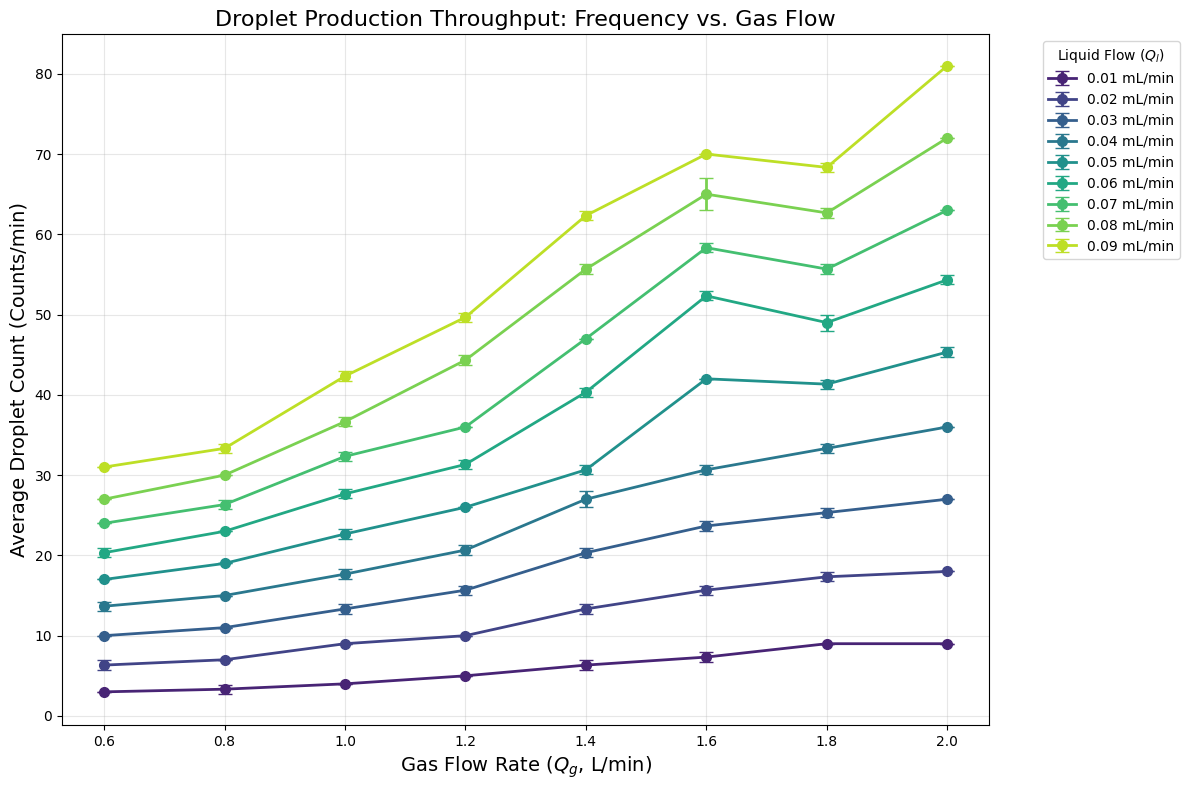

In [ ]:
#RESULTS (PLOTS)
# PLOT 1: DROPLET COUNT VS GAS FLOW RATE
plt.figure(figsize=(12, 8)) # Slightly larger to accommodate 10 legend items

unique_ql = sorted(raw_df['Ql'].unique())
colors = sns.color_palette("viridis", n_colors=len(unique_ql))

for i, ql_val in enumerate(unique_ql):
    subset = raw_df[raw_df['Ql'] == ql_val].sort_values("Qg")

    plt.errorbar(
        subset['Qg'],
        subset['Avg_C'],
        yerr=subset['Std_C'],
        label=f"{ql_val} mL/min",
        color=colors[i],
        marker='o',
        capsize=5,        # Adds the horizontal caps to error bars
        linestyle='-',
        linewidth=2,
        markersize=7
    )

plt.xlabel(r"Gas Flow Rate ($Q_g$, L/min)", fontsize=14)
plt.ylabel(r"Average Droplet Count (Counts/min)", fontsize=14)
plt.title("Droplet Production Throughput: Frequency vs. Gas Flow", fontsize=16)

# Force the legend to show all 10 flow rates
plt.legend(title=r"Liquid Flow ($Q_l$)", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.grid(True, which="both", ls="-", alpha=0.3)
plt.tight_layout()

plt.savefig("Plot_Count_vs_Qg_ErrorBars.png", dpi=300)
plt.show()

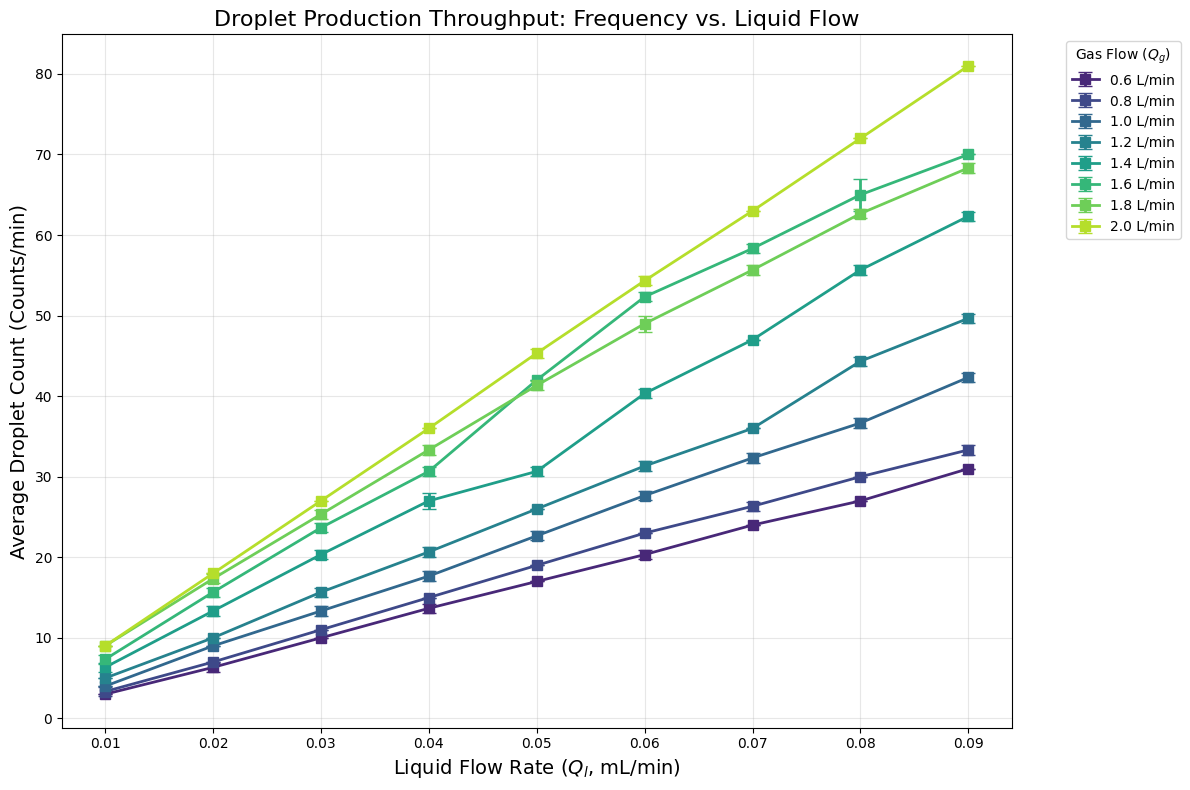

In [ ]:
#RESULTS (PLOTS)
# PLOT 2: DROPLET COUNT VS LQUID FLOW RATE
plt.figure(figsize=(12, 8)) # Slightly larger to accommodate 10 legend items

unique_qg = sorted(raw_df['Qg'].unique())
colors = sns.color_palette("viridis", n_colors=len(unique_qg))

for i, qg_val in enumerate(unique_qg):
    subset = raw_df[raw_df['Qg'] == qg_val].sort_values("Ql")

    plt.errorbar(
        subset['Ql'],
        subset['Avg_C'],
        yerr=subset['Std_C'],
        label=f"{qg_val} L/min",
        color=colors[i],
        marker='s',
        capsize=5,        # Adds the horizontal caps to error bars
        linestyle='-',
        linewidth=2,
        markersize=7
    )

plt.xlabel(r"Liquid Flow Rate ($Q_l$, mL/min)", fontsize=14)
plt.ylabel(r"Average Droplet Count (Counts/min)", fontsize=14)
plt.title("Droplet Production Throughput: Frequency vs. Liquid Flow", fontsize=16)

# Force the legend to show all 10 flow rates
plt.legend(title=r"Gas Flow ($Q_g$)", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.grid(True, which="both", ls="-", alpha=0.3)
plt.tight_layout()

plt.savefig("Plot_Count_vs_Ql_ErrorBars.png", dpi=300)
plt.show()

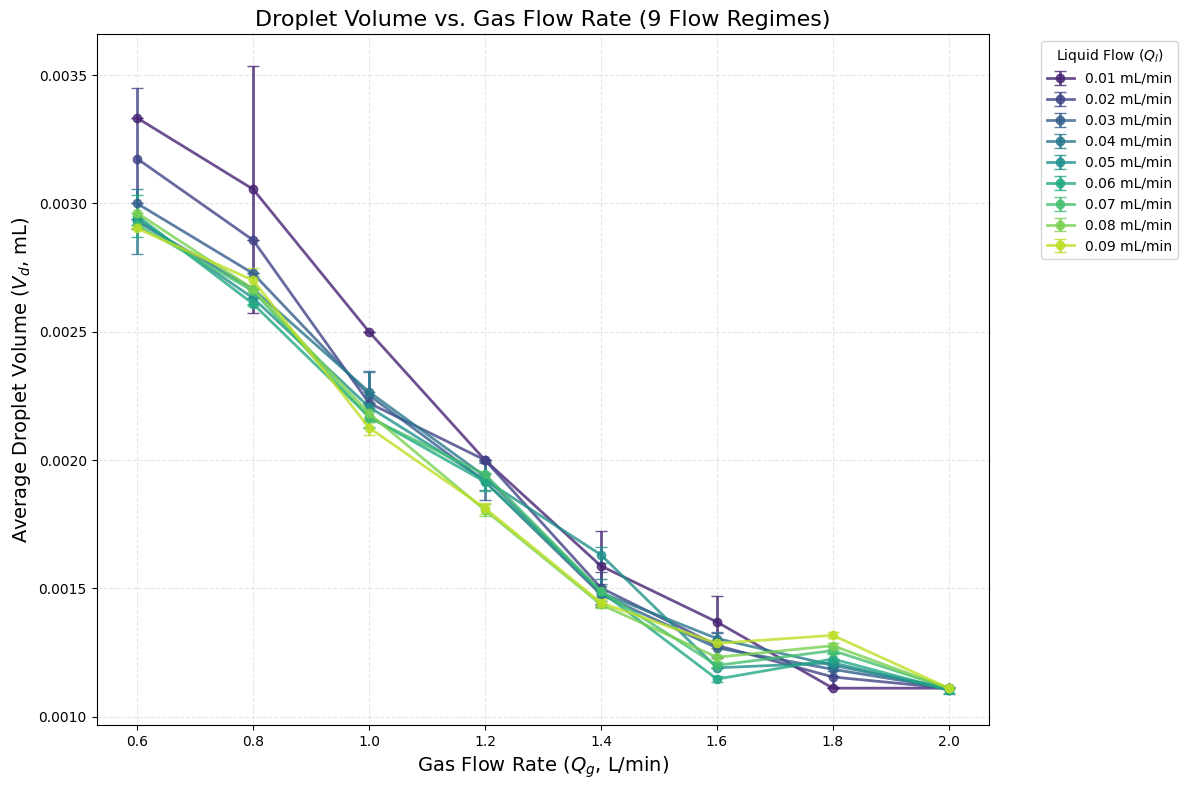

In [ ]:
#PLOT 3: DROPLET VOLUME VS GAS FLOW RATE
plt.figure(figsize=(12, 8))

# Sorting unique liquid flow rates to ensure a logical color gradient
unique_ql = sorted(raw_df['Ql'].unique())
colors = sns.color_palette("viridis", n_colors=len(unique_ql))

# Looping through each of the 10 liquid flow rates to plot individual lines + error bars
for i, ql_val in enumerate(unique_ql):
    # Filter data for the specific liquid flow rate and sort by Gas Flow (X-axis)
    subset = raw_df[raw_df['Ql'] == ql_val].sort_values("Qg")

    plt.errorbar(
        subset['Qg'],
        subset['Avg_V'],
        yerr=subset['Std_V'],
        label=f"{ql_val} mL/min",
        color=colors[i],
        marker='o',
        capsize=4,        # Adds small horizontal caps to the error bars
        linestyle='-',
        linewidth=2,
        markersize=6,
        alpha=0.8         # Slight transparency helps if lines overlap
    )

# Formatting with LaTeX and professional labels
plt.xlabel(r"Gas Flow Rate ($Q_g$, L/min)", fontsize=14)
plt.ylabel(r"Average Droplet Volume ($V_d$, mL)", fontsize=14)
plt.title("Droplet Volume vs. Gas Flow Rate (9 Flow Regimes)", fontsize=16)

# Positioning the legend to show all 10 flow rates clearly
plt.legend(title=r"Liquid Flow ($Q_l$)", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()

# Save high-resolution PNG
plt.savefig("Plot_Volume_vs_Qg_ErrorBars.png", dpi=300)
plt.show()

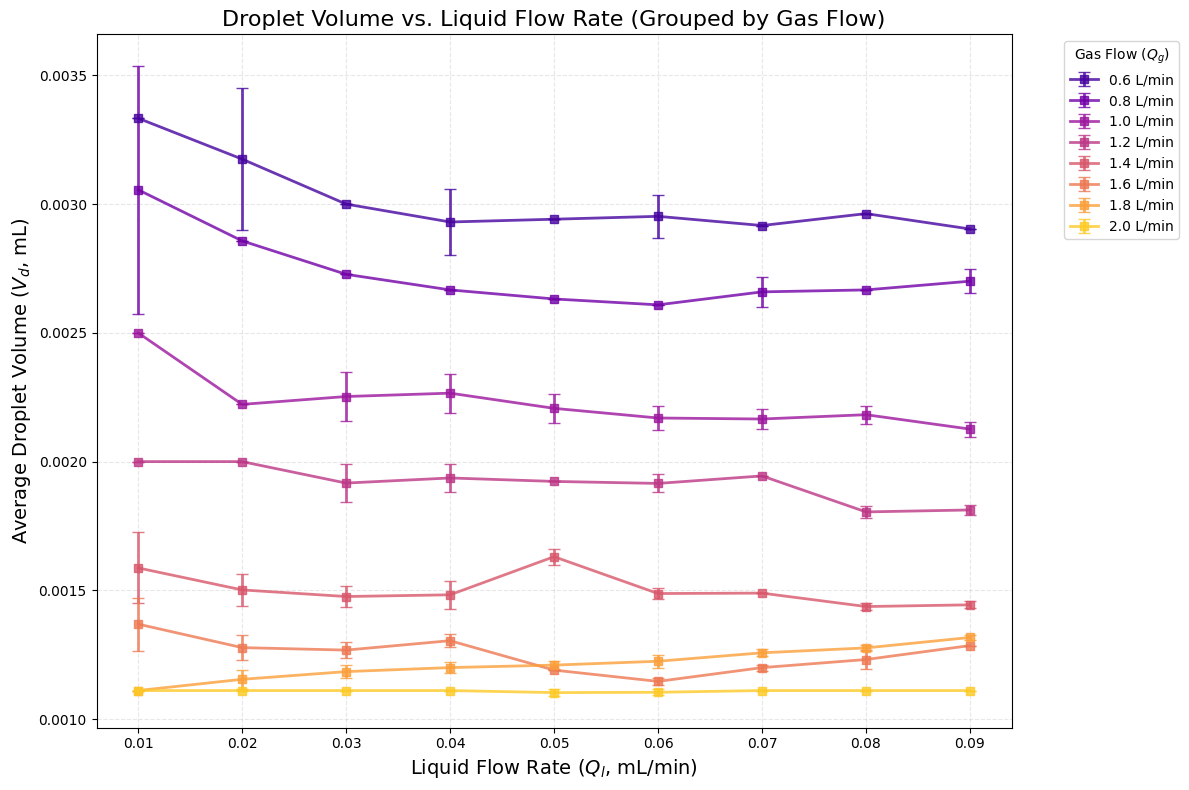

In [ ]:
# PLOT 4: DROPLET VOLUME VS LIQUID FLOW RATE
plt.figure(figsize=(12, 8))

# Grouping by unique Gas Flow rates (Qg) instead of Ql
unique_qg = sorted(raw_df['Qg'].unique())
colors = sns.color_palette("plasma", n_colors=len(unique_qg))

# Loop through each gas flow rate to see how volume changes with liquid flow
for i, qg_val in enumerate(unique_qg):
    # Filter for specific Qg and sort by Ql (X-axis)
    subset = raw_df[raw_df['Qg'] == qg_val].sort_values("Ql")

    plt.errorbar(
        subset['Ql'],
        subset['Avg_V'],
        yerr=subset['Std_V'],
        label=f"{qg_val} L/min",
        color=colors[i],
        marker='s',        # Square markers for variety
        capsize=4,
        linestyle='-',
        linewidth=2,
        markersize=6,
        alpha=0.8
    )

# Formatting with LaTeX
plt.xlabel(r"Liquid Flow Rate ($Q_l$, mL/min)", fontsize=14)
plt.ylabel(r"Average Droplet Volume ($V_d$, mL)", fontsize=14)
plt.title("Droplet Volume vs. Liquid Flow Rate (Grouped by Gas Flow)", fontsize=16)

# Legend showing the different gas flow regimes
plt.legend(title=r"Gas Flow ($Q_g$)", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()

# Save high-resolution PNG
plt.savefig("Plot_Volume_vs_Ql_ErrorBars.png", dpi=300)
plt.show()

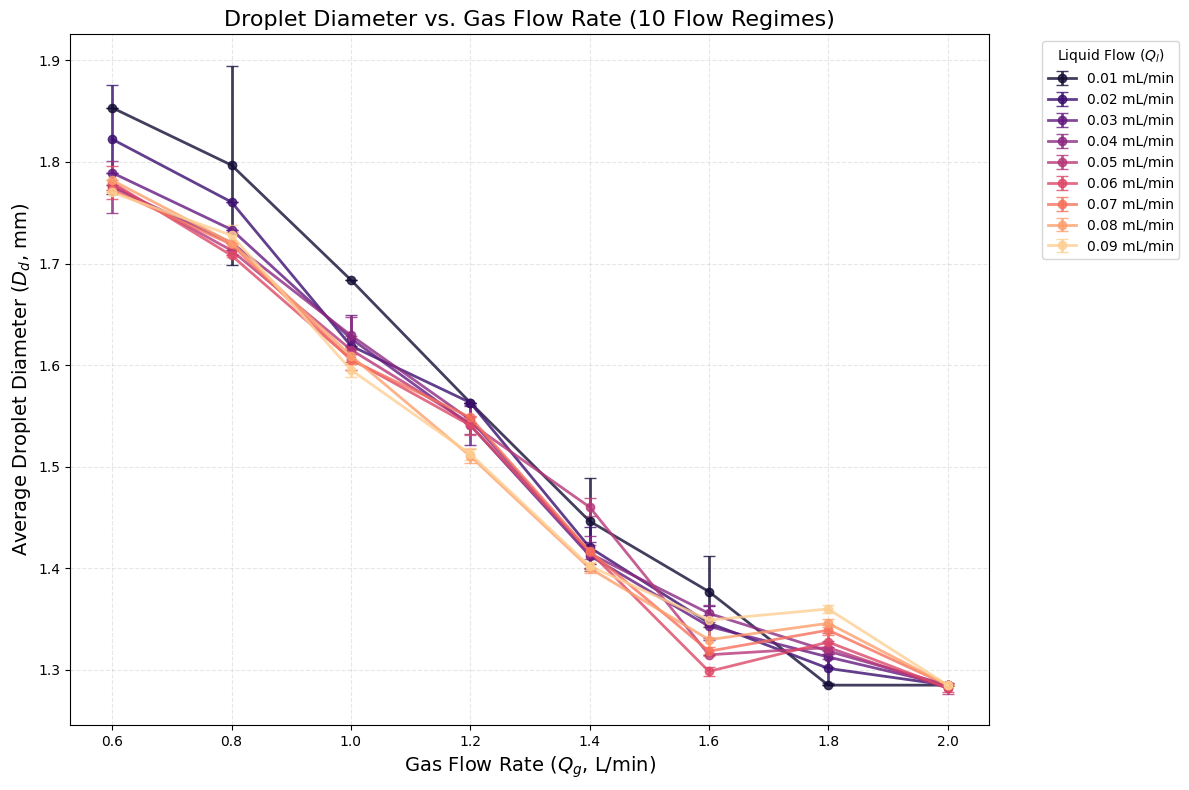

In [ ]:
#PLOT 5: DROPLET DIAMETER VS GAS FLOW RATE
plt.figure(figsize=(12, 8))

# Sorting unique liquid flow rates for a logical color gradient
unique_ql = sorted(raw_df['Ql'].unique())
colors = sns.color_palette("magma", n_colors=len(unique_ql))

# Loop through each of the 10 liquid flow rates
for i, ql_val in enumerate(unique_ql):
    # Filter data and sort by Gas Flow (X-axis)
    subset = raw_df[raw_df['Ql'] == ql_val].sort_values("Qg")

    plt.errorbar(
        subset['Qg'],
        subset['Avg_D'],
        yerr=subset['Std_D'],
        label=f"{ql_val} mL/min",
        color=colors[i],
        marker='o',
        capsize=4,
        linestyle='-',
        linewidth=2,
        markersize=6,
        alpha=0.8
    )

# Formatting with LaTeX and professional labels
plt.xlabel(r"Gas Flow Rate ($Q_g$, L/min)", fontsize=14)
plt.ylabel(r"Average Droplet Diameter ($D_d$, mm)", fontsize=14)
plt.title("Droplet Diameter vs. Gas Flow Rate (10 Flow Regimes)", fontsize=16)

# Positioning the legend to show all 10 flow rates clearly
plt.legend(title=r"Liquid Flow ($Q_l$)", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()

# Save high-resolution PNG
plt.savefig("Plot_Diameter_vs_Qg_ErrorBars.png", dpi=300)
plt.show()

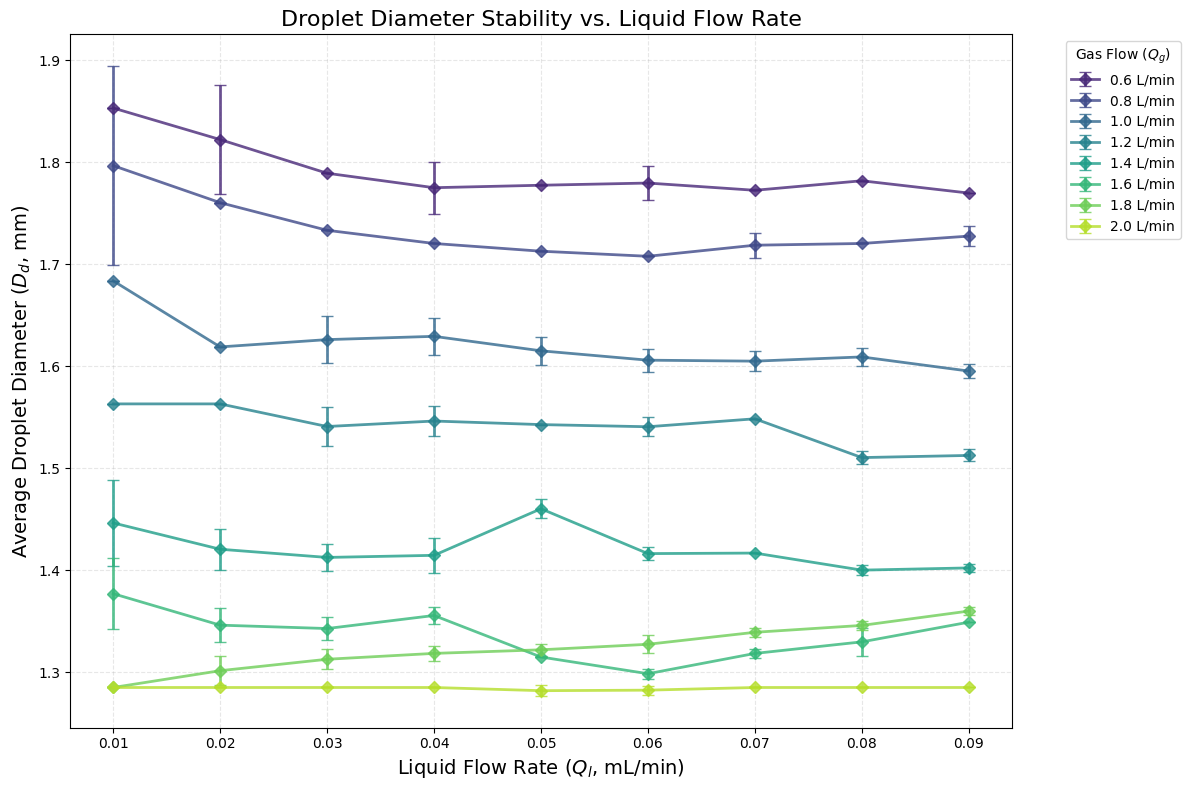

In [ ]:
# PLOT 6: DROPLET DIAMETER VS LIQUID FLOW RATE
plt.figure(figsize=(12, 8))

# Now we group by unique Gas Flow rates (Qg)
unique_qg = sorted(raw_df['Qg'].unique())
# Using 'viridis' or 'plasma' to distinguish the different gas pressures
colors = sns.color_palette("viridis", n_colors=len(unique_qg))

# Loop through each gas flow rate to show diameter trends
for i, qg_val in enumerate(unique_qg):
    # Filter for specific Qg and sort by Ql (X-axis)
    subset = raw_df[raw_df['Qg'] == qg_val].sort_values("Ql")

    plt.errorbar(
        subset['Ql'],
        subset['Avg_D'],
        yerr=subset['Std_D'],
        label=f"{qg_val} L/min",
        color=colors[i],
        marker='D',        # Diamond marker for a distinct look
        capsize=4,
        linestyle='-',
        linewidth=2,
        markersize=6,
        alpha=0.8
    )

# Formatting with LaTeX
plt.xlabel(r"Liquid Flow Rate ($Q_l$, mL/min)", fontsize=14)
plt.ylabel(r"Average Droplet Diameter ($D_d$, mm)", fontsize=14)
plt.title("Droplet Diameter Stability vs. Liquid Flow Rate", fontsize=16)

# Legend showing the different gas flow regimes
plt.legend(title=r"Gas Flow ($Q_g$)", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()

# Save high-resolution PNG
plt.savefig("Plot_Diameter_vs_Ql_ErrorBars.png", dpi=300)
plt.show()

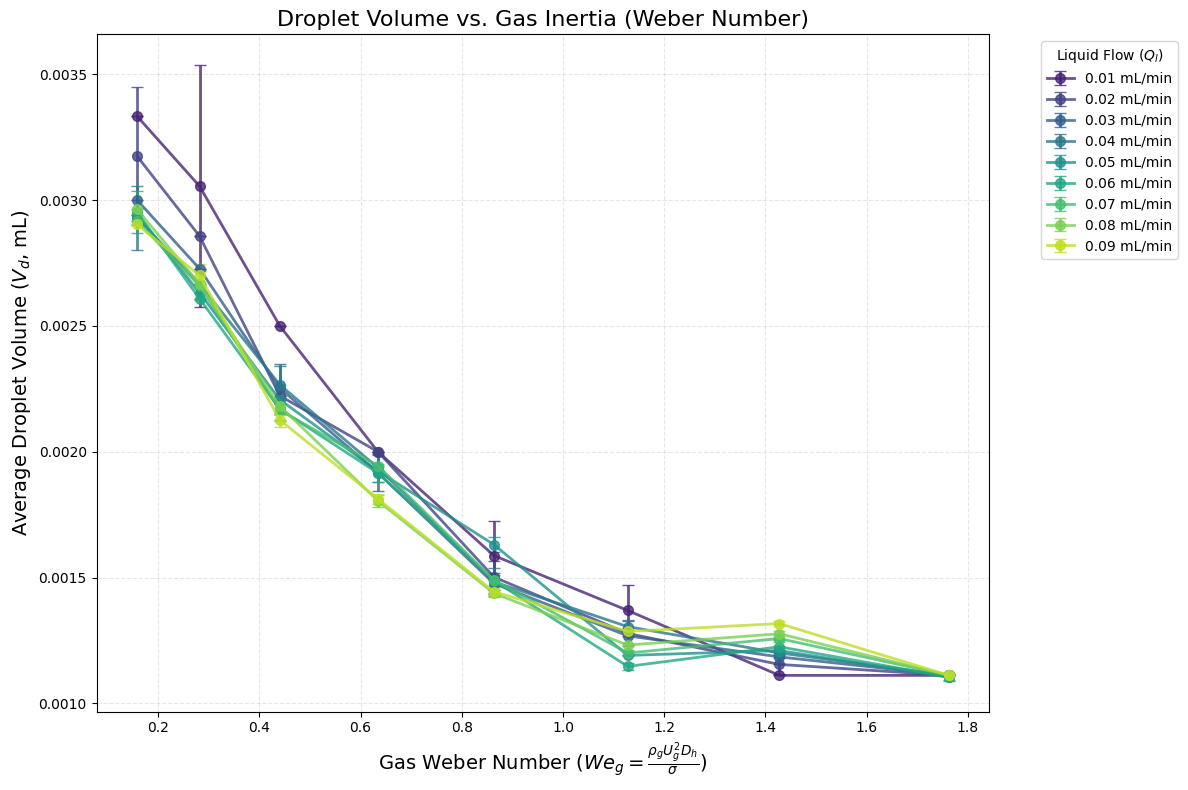

In [ ]:
#PLOT 8: DROPLET VOLUME VS WEBER NUMBER (PHYSICS MAP)
plt.figure(figsize=(12, 8))

unique_ql = sorted(raw_df['Ql'].unique())
colors = sns.color_palette("viridis", n_colors=len(unique_ql))

# Loop through each of the 10 liquid flow rates to show individual physics trends
for i, ql_val in enumerate(unique_ql):
    subset = raw_df[raw_df['Ql'] == ql_val].sort_values("We_g")

    plt.errorbar(
        subset['We_g'],
        subset['Avg_V'],
        yerr=subset['Std_V'],
        label=f"{ql_val} mL/min",
        color=colors[i],
        marker='o',
        capsize=4,
        linestyle='-',
        linewidth=2,
        markersize=7,
        alpha=0.8
    )

# Formatting with LaTeX
plt.xlabel(r"Gas Weber Number ($We_g = \frac{\rho_g U_g^2 D_h}{\sigma}$)", fontsize=14)
plt.ylabel(r"Average Droplet Volume ($V_d$, mL)", fontsize=14)
plt.title("Droplet Volume vs. Gas Inertia (Weber Number)", fontsize=16)

# Positioning the legend for 10 liquid flow rates
plt.legend(title=r"Liquid Flow ($Q_l$)", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()

# Save high-resolution PNG for your report
plt.savefig("Plot_Volume_vs_Weber_ErrorBars.png", dpi=300)
plt.show()

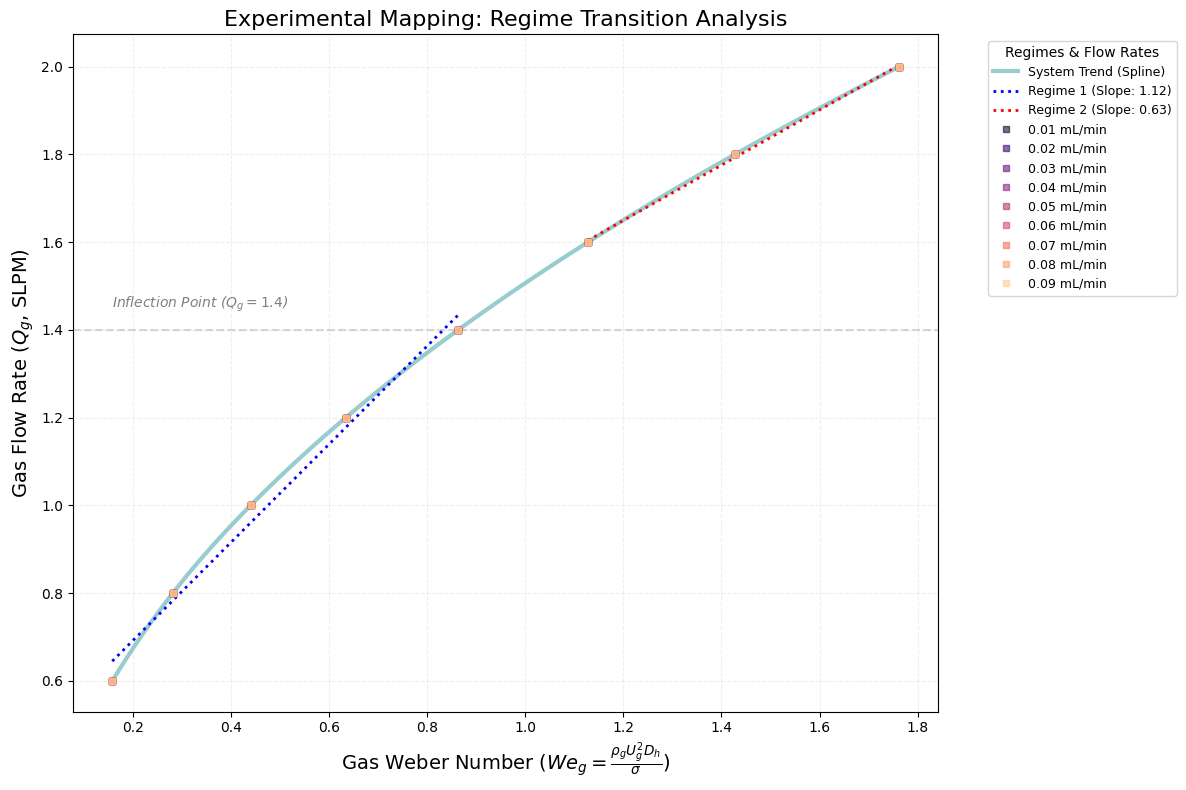

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from scipy.stats import linregress

# PLOT 7: GAS FLOW RATE VS WEBER NUMBER (WITH REGIME ANALYSIS)
plt.figure(figsize=(12, 8))

# 1. GENERATE THE SMOOTH MASTER TRENDLINE
# Group by Weber to get unique points for the spline (avoids the Duplicate X error)
trend_data = raw_df.groupby('We_g')['Qg'].mean().reset_index().sort_values('We_g')
x_pts = trend_data['We_g'].values
y_pts = trend_data['Qg'].values

# Create spline for the teal background curve
x_smooth = np.linspace(x_pts.min(), x_pts.max(), 300)
spline = make_interp_spline(x_pts, y_pts, k=3)
y_smooth = spline(x_smooth)

plt.plot(x_smooth, y_smooth, color='teal', linewidth=3, alpha=0.4, label='System Trend (Spline)', zorder=1)

# 2. CALCULATE AND PLOT THE TWO REGIME SLOPES
# Regime 1: Below 1.4 (Surface Tension/Dripping)
r1_df = trend_data[trend_data['Qg'] <= 1.4]
s1, i1, _, _, _ = linregress(r1_df['We_g'], r1_df['Qg'])
plt.plot(r1_df['We_g'], s1*r1_df['We_g'] + i1, color='blue', linestyle=':', linewidth=2, label=f'Regime 1 (Slope: {s1:.2f})')

# Regime 2: Above 1.4 (Inertial/Inconsistent)
r2_df = trend_data[trend_data['Qg'] > 1.4]
s2, i2, _, _, _ = linregress(r2_df['We_g'], r2_df['Qg'])
plt.plot(r2_df['We_g'], s2*r2_df['We_g'] + i2, color='red', linestyle=':', linewidth=2, label=f'Regime 2 (Slope: {s2:.2f})')

# 3. PLOT ORIGINAL DATA POINTS (Grouped by Ql)
unique_ql = sorted(raw_df['Ql'].unique())
colors = sns.color_palette("magma", n_colors=len(unique_ql))

for i, ql_val in enumerate(unique_ql):
    subset = raw_df[raw_df['Ql'] == ql_val].sort_values("We_g")
    plt.plot(subset['We_g'], subset['Qg'], label=f"{ql_val} mL/min",
             color=colors[i], marker='s', markersize=4, linestyle='', alpha=0.6, zorder=3)

# 4. FORMATTING
plt.axhline(y=1.4, color='gray', linestyle='--', alpha=0.3)
plt.text(x_pts.min(), 1.45, 'Inflection Point ($Q_g = 1.4$)', color='gray', fontsize=10, style='italic')

plt.xlabel(r"Gas Weber Number ($We_g = \frac{\rho_g U_g^2 D_h}{\sigma}$)", fontsize=14)
plt.ylabel(r"Gas Flow Rate ($Q_g$, SLPM)", fontsize=14)
plt.title("Experimental Mapping: Regime Transition Analysis", fontsize=16)

# Legend and Grid
plt.legend(title="Regimes & Flow Rates", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, which="both", ls="--", alpha=0.2)
plt.tight_layout()

plt.savefig("Plot_GasFlow_Regime_Analysis.png", dpi=300)
plt.show()

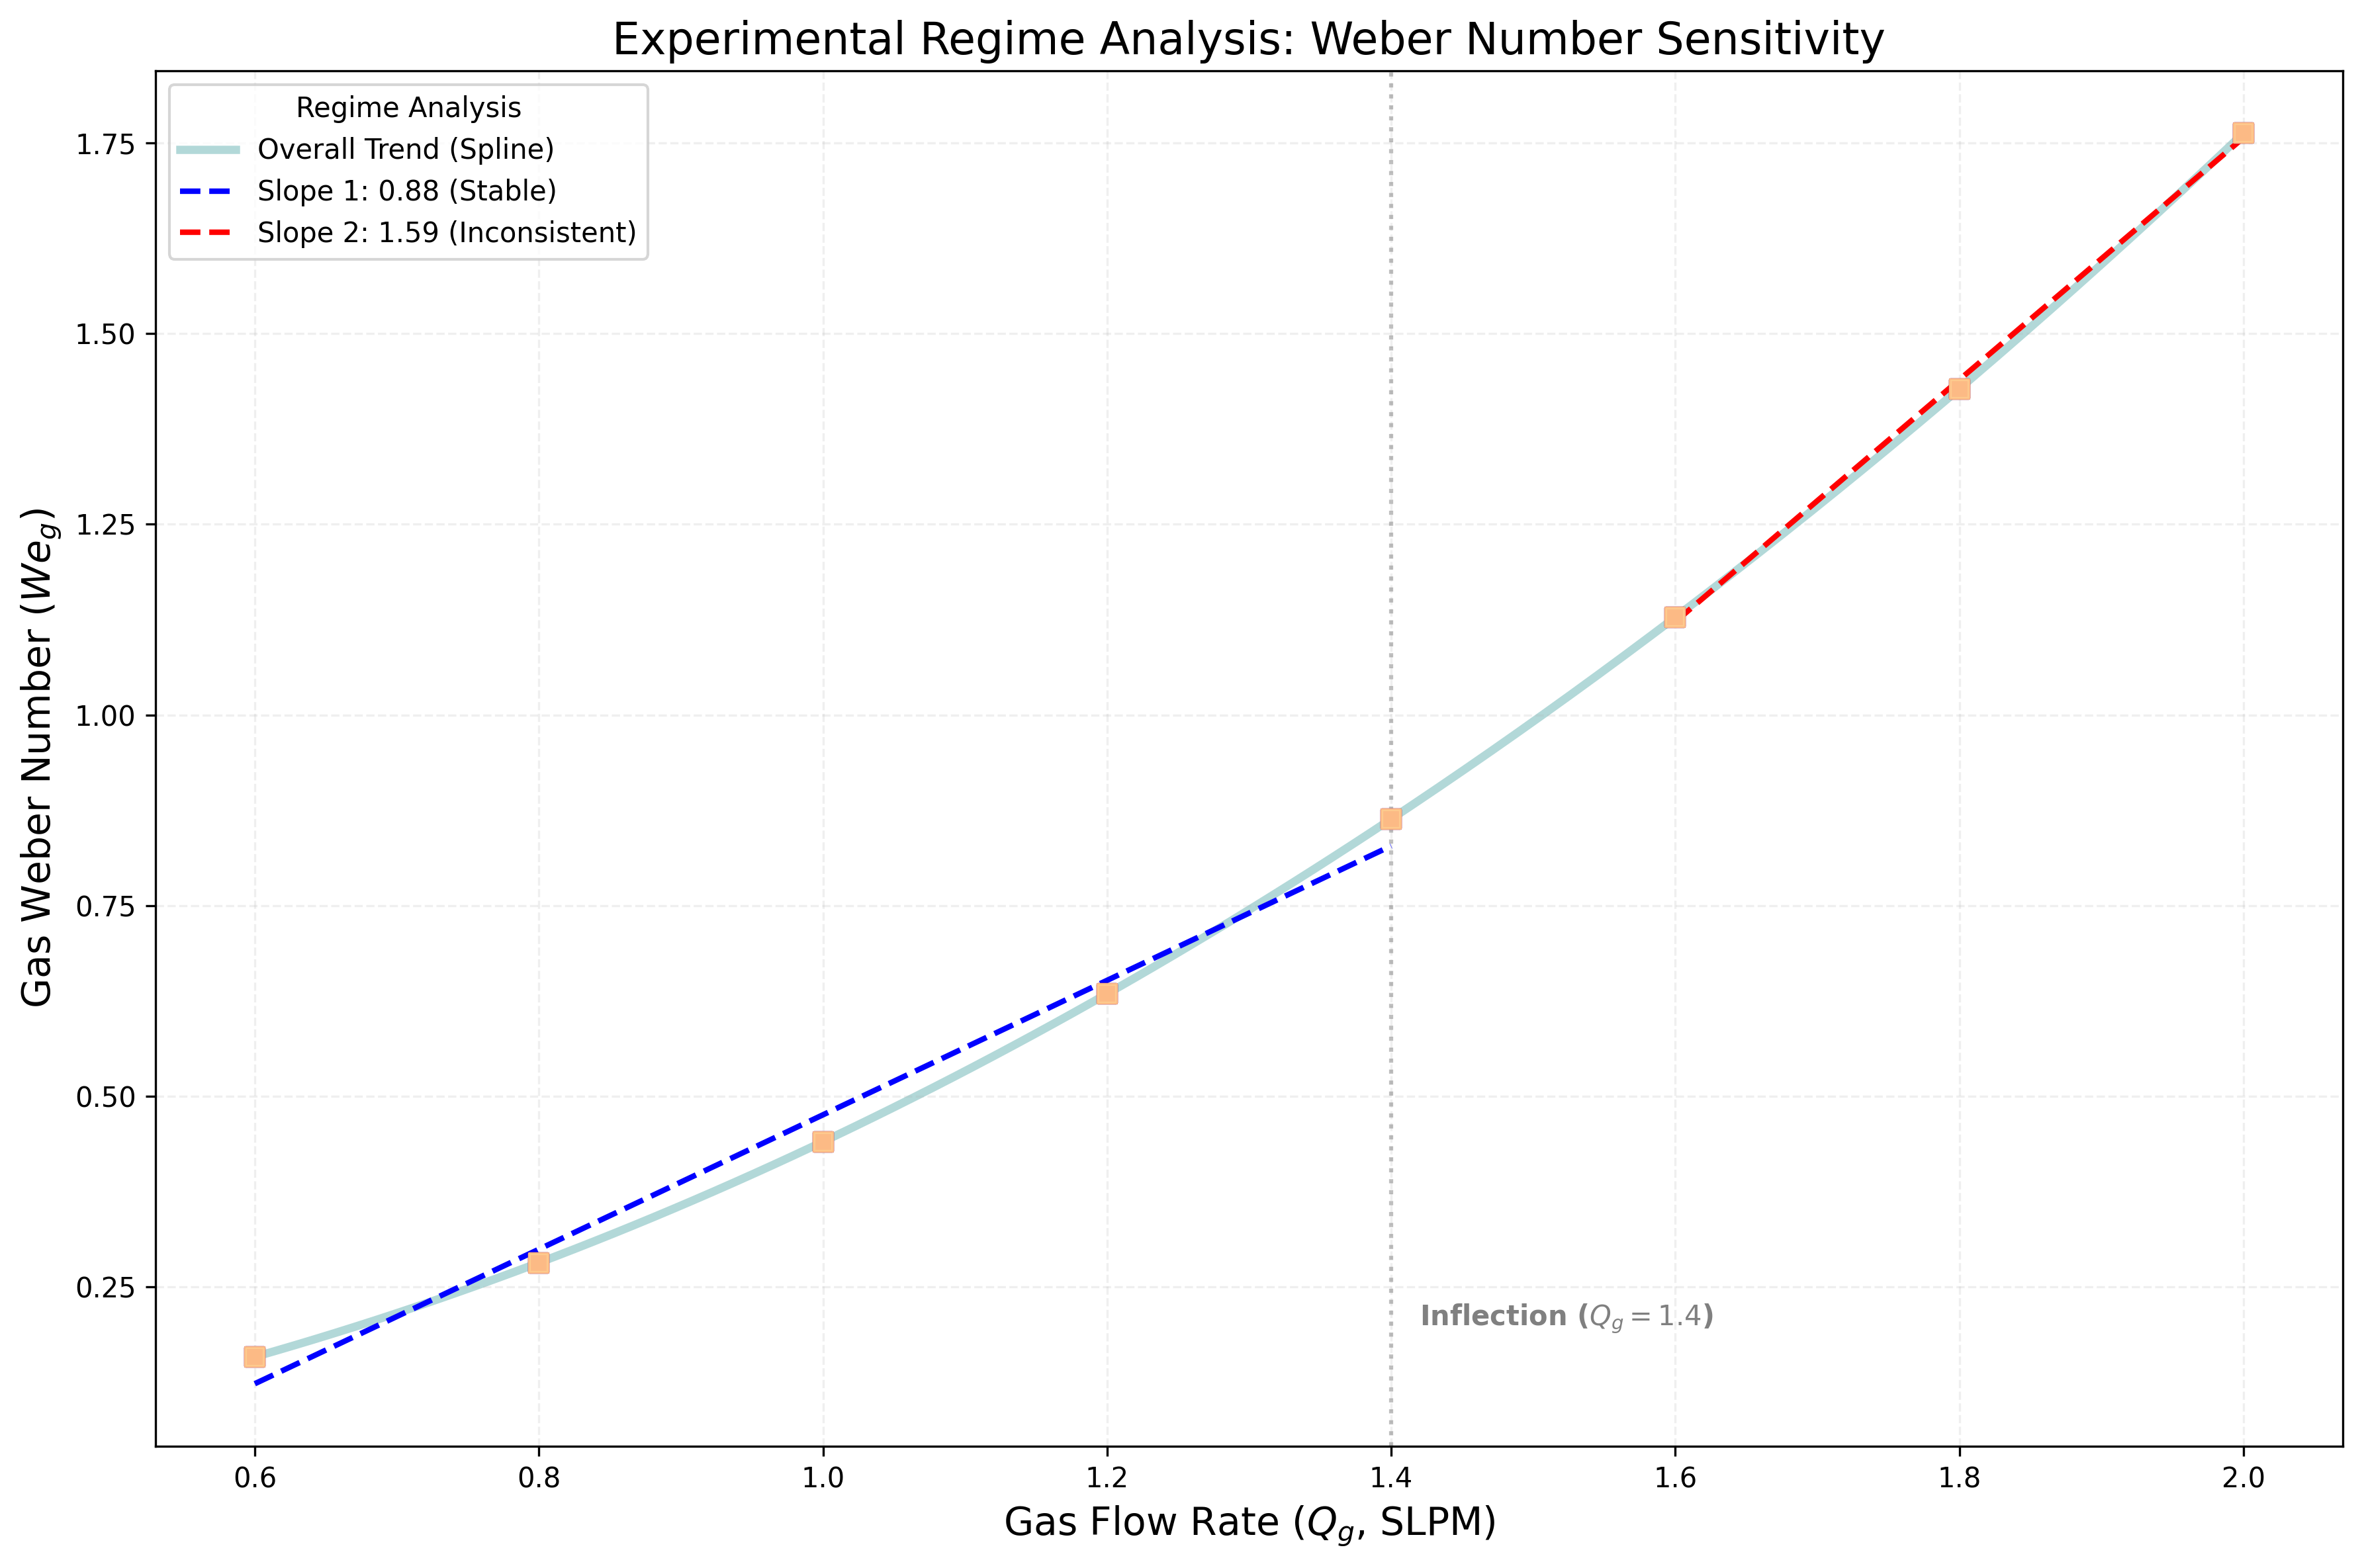

Slope 1 (Initial): 0.8811
Slope 2 (High Flow): 1.5860
Sensitivity Increase: 80.0%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
from scipy.stats import linregress

# PLOT 8: WEBER NUMBER VS GAS FLOW RATE (WITH DUAL SLOPES)
plt.figure(figsize=(12, 8), dpi=300)

# 1. PREPARE THE DATA FOR TRENDLINES
# Group by Qg to get unique points for math operations
trend_data = raw_df.groupby('Qg')['We_g'].mean().reset_index().sort_values('Qg')
x_pts = trend_data['Qg'].values
y_pts = trend_data['We_g'].values

# 2. THE SMOOTH SPLINE (The "Path" of your data)
x_smooth = np.linspace(x_pts.min(), x_pts.max(), 300)
spline = make_interp_spline(x_pts, y_pts, k=3)
y_smooth = spline(x_smooth)
plt.plot(x_smooth, y_smooth, color='teal', linewidth=3, alpha=0.3, label='Overall Trend (Spline)', zorder=1)

# 3. THE TWO TANGENT SLOPES
# Slope 1: Initial Growth (Low Qg <= 1.4)
low_df = trend_data[trend_data['Qg'] <= 1.4]
s1, i1, _, _, _ = linregress(low_df['Qg'], low_df['We_g'])
plt.plot(low_df['Qg'], s1*low_df['Qg'] + i1, color='blue', linestyle='--', linewidth=2,
         label=f'Slope 1: {s1:.2f} (Stable)')

# Slope 2: Accelerated Growth (High Qg > 1.4)
high_df = trend_data[trend_data['Qg'] > 1.4]
s2, i2, _, _, _ = linregress(high_df['Qg'], high_df['We_g'])
plt.plot(high_df['Qg'], s2*high_df['Qg'] + i2, color='red', linestyle='--', linewidth=2,
         label=f'Slope 2: {s2:.2f} (Inconsistent)')

# 4. DATA POINTS BY LIQUID FLOW (Ql)
unique_ql = sorted(raw_df['Ql'].unique())
colors = sns.color_palette("magma", n_colors=len(unique_ql))

for i, ql_val in enumerate(unique_ql):
    subset = raw_df[raw_df['Ql'] == ql_val]
    plt.scatter(subset['Qg'], subset['We_g'], color=colors[i], marker='s', s=45, alpha=0.7, zorder=3)

# 5. FORMATTING
plt.axvline(x=1.4, color='gray', linestyle=':', alpha=0.5)
plt.text(1.42, 0.2, 'Inflection ($Q_g = 1.4$)', color='gray', fontsize=10, fontweight='bold')

plt.ylabel(r"Gas Weber Number ($We_g$)", fontsize=14)
plt.xlabel(r"Gas Flow Rate ($Q_g$, SLPM)", fontsize=14)
plt.title("Experimental Regime Analysis: Weber Number Sensitivity", fontsize=16)

# Legend (Using custom entries to avoid 20 legend items)
plt.legend(title="Regime Analysis", loc='upper left', fontsize=10)
plt.grid(True, which="both", ls="--", alpha=0.2)
plt.tight_layout()

plt.savefig("Plot_Weber_vs_GasFlow_Slopes.png")
plt.show()

# Print the physics summary
print(f"Slope 1 (Initial): {s1:.4f}")
print(f"Slope 2 (High Flow): {s2:.4f}")
print(f"Sensitivity Increase: {((s2 - s1) / s1) * 100:.1f}%")

/tmp/ipykernel_52100/3292217666.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


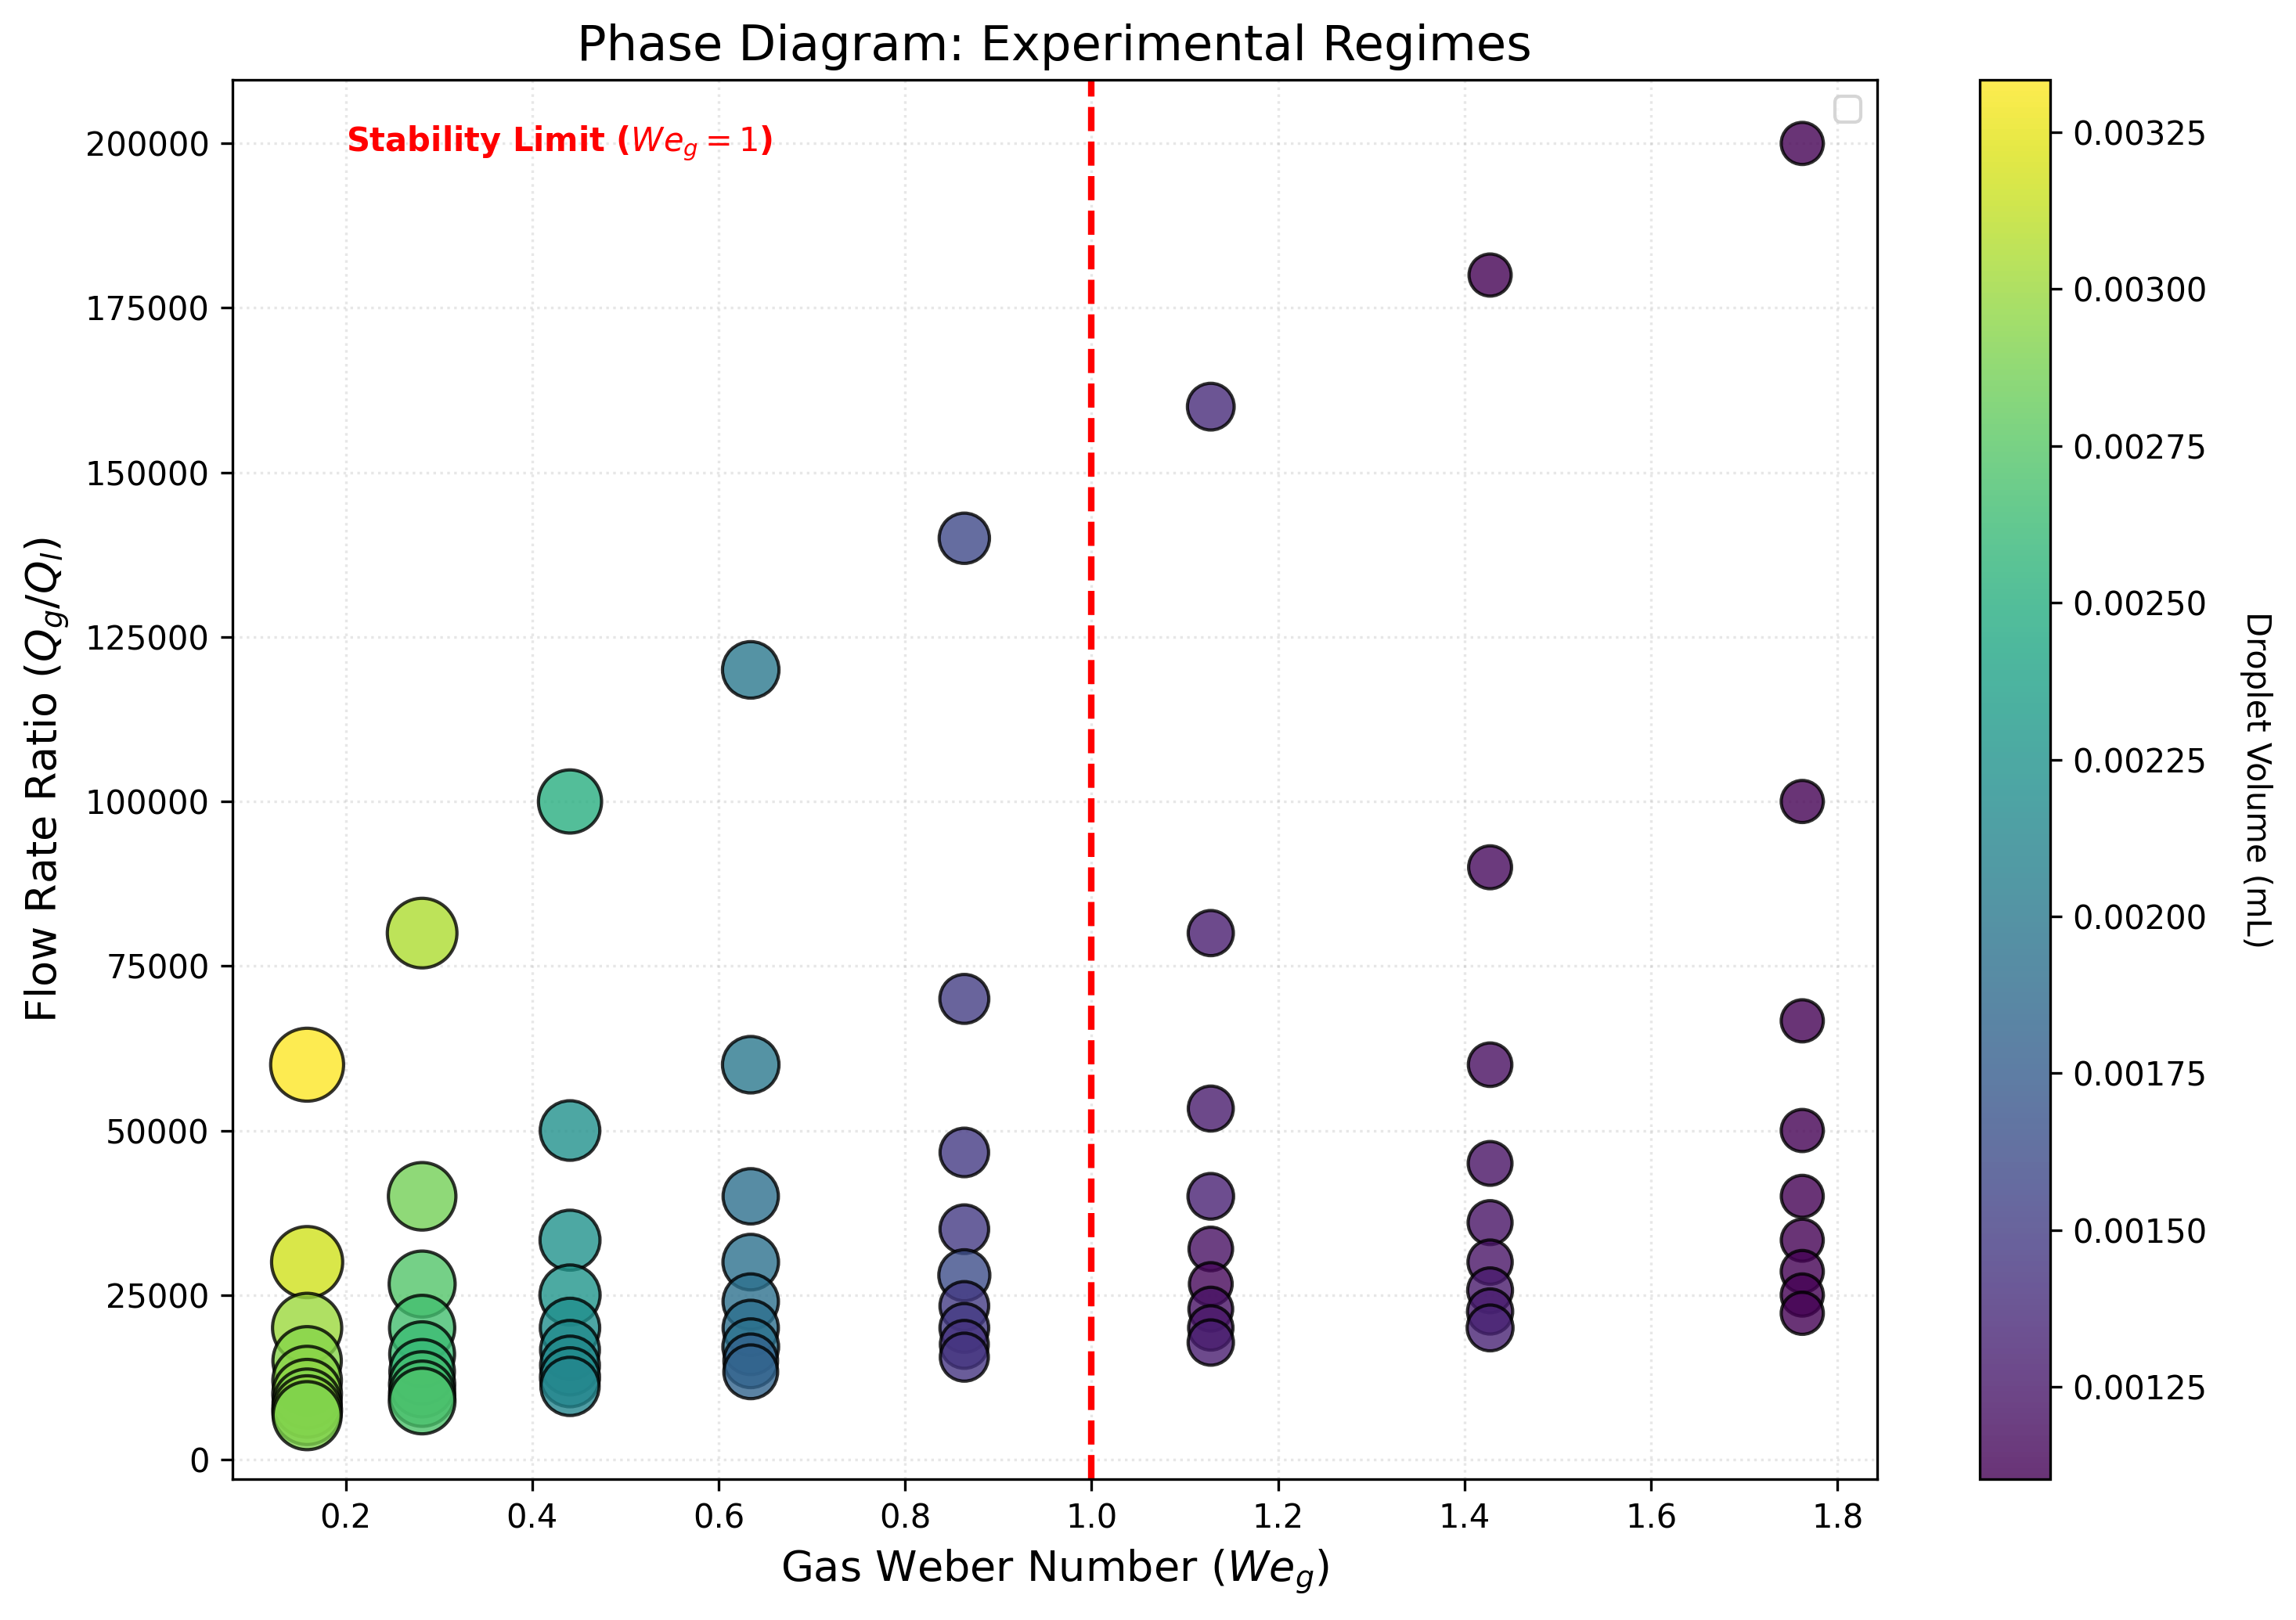

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the momentum/flow ratio
physics_report['Ql (mL/min)'] = physics_report['Ql (mL/min)'] / 1000
physics_report['Ratio'] = physics_report['Qg (L/min)'] / physics_report['Ql (mL/min)']

plt.figure(figsize=(10, 7), dpi=300)

# Scatter plot: color = volume, size = physical diameter representation
scatter = plt.scatter(
    physics_report['Weber (We_g)'],
    physics_report['Ratio'],
    c=physics_report['Droplet Vol (mL)'],
    s=(physics_report['Avg Dia (mm)'] / physics_report['Avg Dia (mm)'].max())**3 * 500,
    cmap='viridis',
    edgecolors='black',
    alpha=0.8,
    zorder=3
)

# Add the critical stability line
# 1. Keep the physical boundary line exactly at 1.0
plt.axvline(x=1.0, color='red', linestyle='--', linewidth=2, zorder=2)

# 2. Move the LABEL to the far left (x=0.15) where there is plenty of room
# This keeps the text completely away from the crowded middle/right sections
max_y = physics_report['Ratio'].max()

plt.text(0.2, max_y, 'Stability Limit ($We_g=1$)',
         color='red',
         fontweight='bold',
         fontsize=10,
         ha='left',   # Align to the left of the x=0.15 point
         va='center',
         rotation=0)  # Horizontal text is much easier to read here

# Labels
plt.xlabel(r"Gas Weber Number ($We_g$)", fontsize=13)
plt.ylabel(r"Flow Rate Ratio ($Q_g / Q_l$)", fontsize=13)
plt.title("Phase Diagram: Experimental Regimes", fontsize=15)

cbar = plt.colorbar(scatter)
cbar.set_label('Droplet Volume (mL)', rotation=270, labelpad=20)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.savefig("Phase_Diagram_Experimental.png")
plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_52100/1734529828.py:46: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_xlabel("$\log_{10}(Q_g)$")
/tmp/ipykernel_52100/1734529828.py:47: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_ylabel("$\log_{10}(We_g)$")


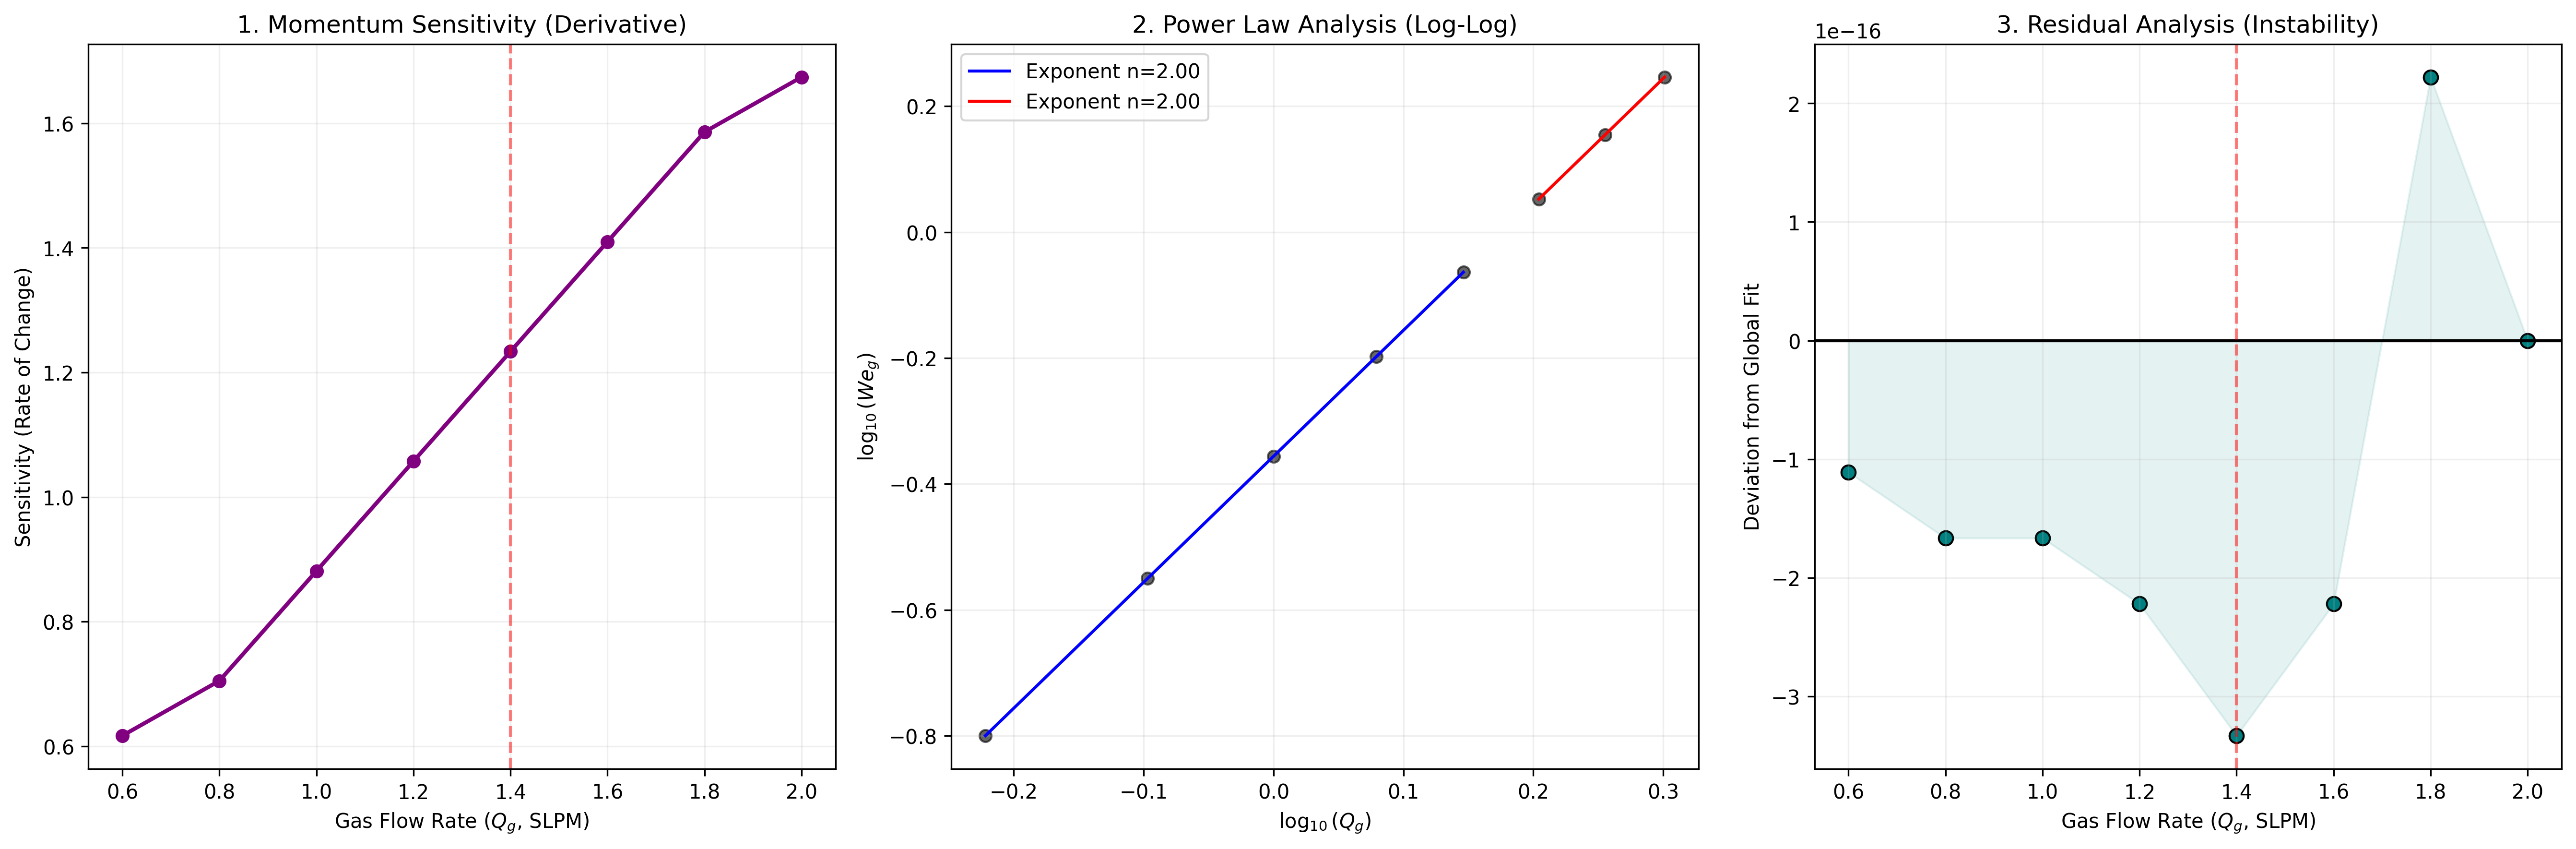

Analysis Complete. Power-law shift: 2.00 to 2.00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# --- 1. DATA PREPARATION ---
# Group by Qg to get a clean average "System Curve" for analysis
analysis_df = raw_df.groupby('Qg')['We_g'].mean().reset_index().sort_values('Qg')
qg = analysis_df['Qg'].values
we = analysis_df['We_g'].values

# Create the 3-panel figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6), dpi=300)

# --- PANEL 1: THE DERIVATIVE (Sensitivity Analysis) ---
# We calculate the rate of change of Weber relative to Flow Rate
# d(We)/d(Qg)
derivative = np.gradient(we, qg)

ax1.plot(qg, derivative, color='purple', marker='o', linewidth=2, label=r'$dWe_g / dQ_g$')
ax1.axvline(x=1.4, color='red', linestyle='--', alpha=0.5)
ax1.set_title("1. Momentum Sensitivity (Derivative)", fontsize=12)
ax1.set_xlabel("Gas Flow Rate ($Q_g$, SLPM)")
ax1.set_ylabel("Sensitivity (Rate of Change)")
ax1.grid(True, alpha=0.2)

# --- PANEL 2: LOG-LOG PLOT (Power Law Exponent) ---
# Transitioning to Log-Log space reveals the underlying physics "Rule"
log_q = np.log10(qg)
log_we = np.log10(we)

# Split and calculate exponents (slopes in log-log space)
mask_low = qg <= 1.4
mask_high = qg > 1.4

slope_low, _, _, _, _ = linregress(log_q[mask_low], log_we[mask_low])
slope_high, _, _, _, _ = linregress(log_q[mask_high], log_we[mask_high])

ax2.scatter(log_q, log_we, color='black', alpha=0.6)
ax2.plot(log_q[mask_low], log_q[mask_low]*slope_low + (log_we[mask_low].mean() - log_q[mask_low].mean()*slope_low),
         color='blue', label=f'Exponent n={slope_low:.2f}')
ax2.plot(log_q[mask_high], log_q[mask_high]*slope_high + (log_we[mask_high].mean() - log_q[mask_high].mean()*slope_high),
         color='red', label=f'Exponent n={slope_high:.2f}')

ax2.set_title("2. Power Law Analysis (Log-Log)", fontsize=12)
ax2.set_xlabel("$\log_{10}(Q_g)$")
ax2.set_ylabel("$\log_{10}(We_g)$")
ax2.legend()
ax2.grid(True, alpha=0.2)

# --- PANEL 3: RESIDUAL ANALYSIS (Noise/Inconsistency) ---
# Fit a global 2nd-degree polynomial and find the deviation
poly_coeffs = np.polyfit(qg, we, 2)
poly_func = np.poly1d(poly_coeffs)
residuals = we - poly_func(qg)

ax3.scatter(qg, residuals, color='teal', s=50, edgecolor='black')
ax3.axhline(y=0, color='black', linestyle='-')
ax3.axvline(x=1.4, color='red', linestyle='--', alpha=0.5)
ax3.fill_between(qg, 0, residuals, alpha=0.1, color='teal')

ax3.set_title("3. Residual Analysis (Instability)", fontsize=12)
ax3.set_xlabel("Gas Flow Rate ($Q_g$, SLPM)")
ax3.set_ylabel("Deviation from Global Fit")
ax3.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("Regime_Transition_Analysis_Triple.png")
plt.show()

print(f"Analysis Complete. Power-law shift: {slope_low:.2f} to {slope_high:.2f}")

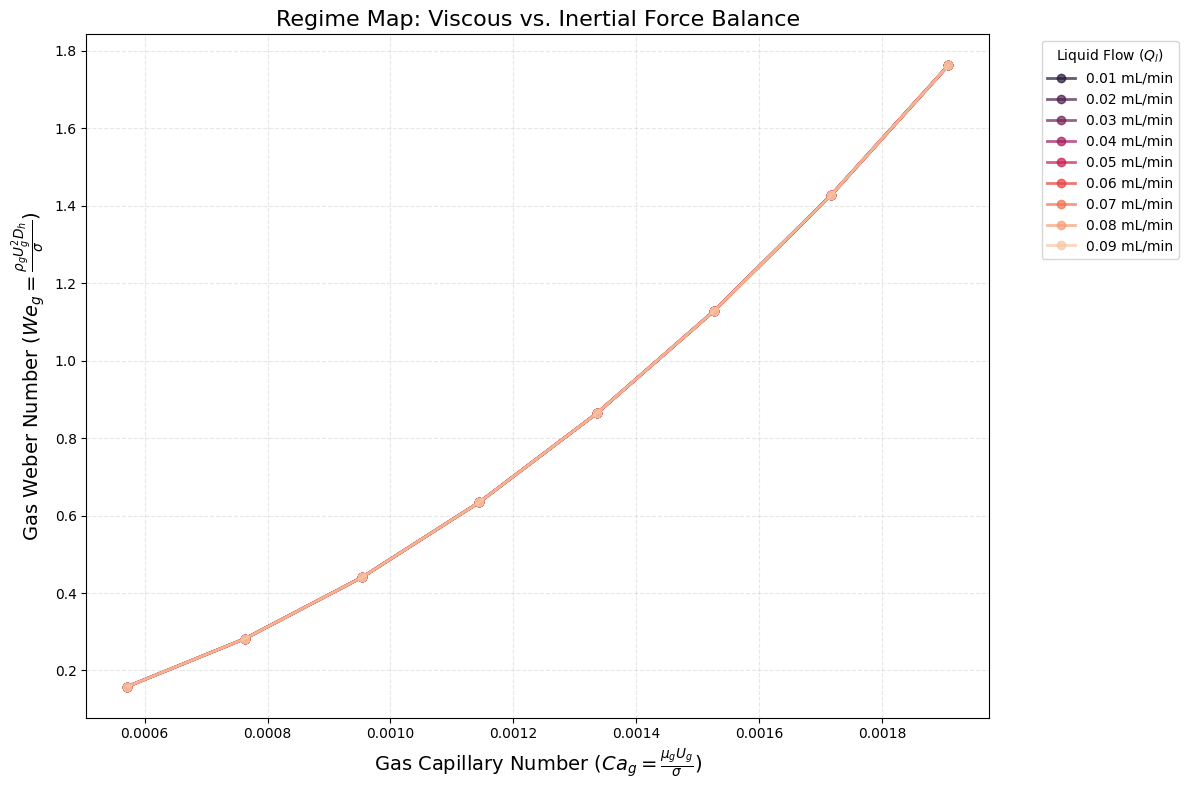

In [ ]:
#PLOT 6: FORCE BALANCE MAP (Ca_g vs. We_g)
plt.figure(figsize=(12, 8))

# Sorting unique liquid flow rates for the legend
unique_ql = sorted(raw_df['Ql'].unique())
colors = sns.color_palette("rocket", n_colors=len(unique_ql))

# Loop through each of the 10 liquid flow rates to show the 'Operating Trajectory'
for i, ql_val in enumerate(unique_ql):
    subset = raw_df[raw_df['Ql'] == ql_val].sort_values("Ca_g")

    # We plot the lines to show how the force balance shifts as you increase gas flow
    plt.plot(
        subset['Ca_g'],
        subset['We_g'],
        label=f"{ql_val} mL/min",
        color=colors[i],
        marker='o',
        linestyle='-',
        linewidth=2,
        markersize=6,
        alpha=0.7
    )

# Formatting with LaTeX for professional physics labels
plt.xlabel(r"Gas Capillary Number ($Ca_g = \frac{\mu_g U_g}{\sigma}$)", fontsize=14)
plt.ylabel(r"Gas Weber Number ($We_g = \frac{\rho_g U_g^2 D_h}{\sigma}$)", fontsize=14)
plt.title("Regime Map: Viscous vs. Inertial Force Balance", fontsize=16)

# Positioning the legend for 10 liquid flow rates
plt.legend(title=r"Liquid Flow ($Q_l$)", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()

# Save high-resolution PNG
plt.savefig("Plot_RegimeMap_Trends.png", dpi=300)
plt.show()